In [18]:
import numpy as np
import matplotlib.pylab as plt
from matplotlib.image import imread
import os

In [25]:
# lets perform an svd
X = np.random.rand(5,3)
U, S, VT = np.linalg.svd(X, full_matrices=True)
Uhat, Shat, VThat = np.linalg.svd(X,full_matrices=False)

In [26]:
X

array([[0.13447669, 0.73996295, 0.05036067],
       [0.56336607, 0.76863311, 0.92823309],
       [0.60672364, 0.19030131, 0.31308364],
       [0.93180659, 0.94120819, 0.15429825],
       [0.01156606, 0.84538299, 0.66371705]])

In [27]:
U

array([[-0.29202788, -0.03467907, -0.64119491, -0.65619046, -0.2679557 ],
       [-0.58543678, -0.27664104,  0.4926685 ,  0.03082627, -0.58056955],
       [-0.26709717,  0.33028737,  0.48868926, -0.57862296,  0.49593108],
       [-0.56063206,  0.63928291, -0.2652978 ,  0.45064896,  0.05951173],
       [-0.43166456, -0.63599899, -0.19221531,  0.17485654,  0.58450788]])

In [31]:
np.diag(S)

array([[2.17731846, 0.        , 0.        ],
       [0.        , 0.79757641, 0.        ],
       [0.        , 0.        , 0.62987043]])

In [29]:
VT

array([[-0.4861639 , -0.73921121, -0.46605949],
       [ 0.78765053, -0.1396819 , -0.60007967],
       [ 0.37848555, -0.65882908,  0.65014839]])

In [11]:
Uhat

array([[-0.04015041, -0.01898416, -0.30659235],
       [-0.46754213, -0.27950008, -0.71395113],
       [-0.53960377, -0.2664408 ,  0.0612538 ],
       [-0.65357402,  0.07234267,  0.57412837],
       [-0.24791344,  0.91939934, -0.25079773]])

In [13]:
Shat

array([1.89286854, 0.39182028, 0.29889768])

In [14]:
VThat

array([[-0.18518195, -0.62569925, -0.75776519],
       [ 0.03119921, -0.77445663,  0.63185721],
       [-0.98220886,  0.09336688,  0.16293671]])

In [37]:
Uhat @ np.diag(Shat) @ VThat

array([[0.13447669, 0.73996295, 0.05036067],
       [0.56336607, 0.76863311, 0.92823309],
       [0.60672364, 0.19030131, 0.31308364],
       [0.93180659, 0.94120819, 0.15429825],
       [0.01156606, 0.84538299, 0.66371705]])

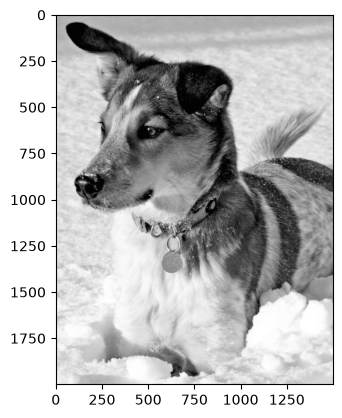

In [38]:
# lets read an image of a snow dog
A = imread(os.path.join('..','DATA','dog.jpg'))
X = np.mean(A, -1); # Convert RGB to grayscale
img = plt.imshow(X, cmap='gray')
# Take the SVD
U, S, VT = np.linalg.svd(X,full_matrices=False)
S = np.diag(S) # Approximate matrix with truncated SVD for various ranks r

In [20]:
X

array([[175.33333333, 174.33333333, 171.33333333, ..., 175.33333333,
        175.        , 172.        ],
       [171.33333333, 171.33333333, 172.33333333, ..., 175.33333333,
        175.33333333, 172.        ],
       [174.        , 176.        , 178.        , ..., 174.66666667,
        174.33333333, 172.33333333],
       ...,
       [246.        , 246.        , 246.        , ..., 215.33333333,
        215.66666667, 216.66666667],
       [247.        , 246.        , 246.        , ..., 214.33333333,
        214.66666667, 215.66666667],
       [247.        , 246.        , 246.        , ..., 215.33333333,
        214.66666667, 215.66666667]], shape=(2000, 1500))

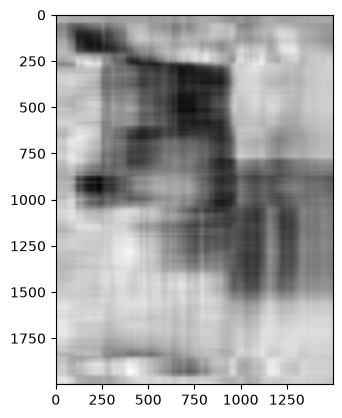

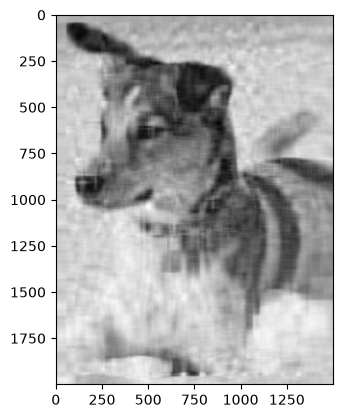

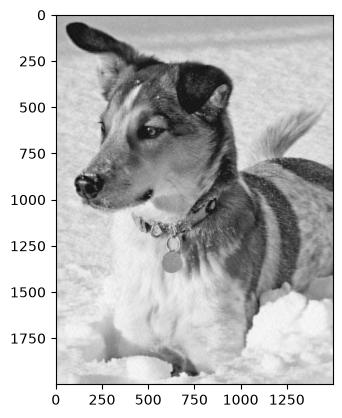

In [42]:
for r in (5, 20, 100): # Construct approximate image
    Xapprox = U[:,:r] @ S[0:r,:r] @ VT[:r,:]
    img = plt.imshow(Xapprox, cmap='gray')
    plt.show() # Plot singular values and cumulative sum

Text(0, 0.5, 'singular value')

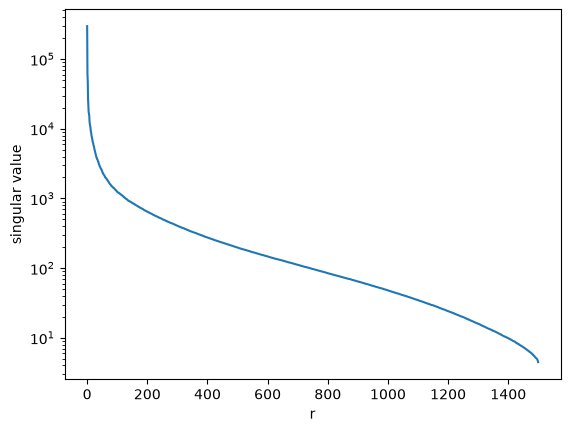

In [44]:
plt.semilogy(np.diag(S))
plt.xlabel("r")
plt.ylabel("singular value")

Text(0, 0.5, 'cummulative sum normalized')

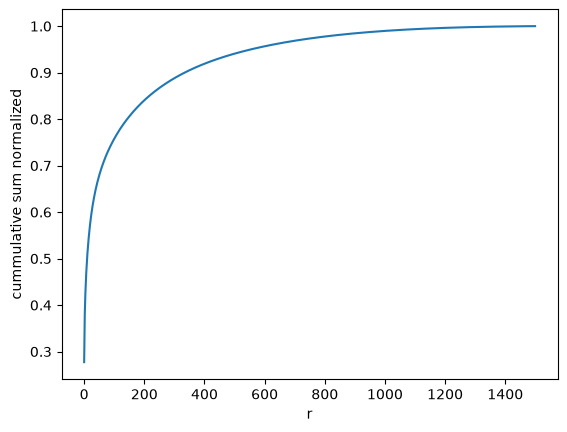

In [45]:
plt.plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))
plt.xlabel("r")
plt.ylabel("cummulative sum normalized")